In [1]:
from src.train import train_model
from src.extractor import run_full_extraction_pipeline
from src.run_cali import run_cali
from src.evaluation import compare_methods

seed = 0

# For an simpler and get the same results as in the paper, we advise you to download the classifiers's checkpoints from **[[HERE](https://osf.io/k2tgw/overview?view_only=b53979387b844dd195832d3cb9a9bbfa)]** and place it in `models/`
# If you want to train the model locally, run: train_model(seed=seed)

run_full_extraction_pipeline(seed=seed)
run_cali(seed=seed)
metrics_table, detailed_results = compare_methods(seed=seed)

[SKIP EXTRACTION] cifar10 | seed 0 - feature files already exist.
--- CALI metrics cifar10_resnet ---
(0.9099602160160587, 0.4153182308522114, 0.9872677579614599, 0.5688751120424087, 0.6100872084829319, 16.149315970600593, 11.708751155379604)

--- Confidence Metrics Comparison ---
                   WAE_Cali  Softmax  TrustScore  EnergyScore  MC_Dropout
AUROC                0.9100   0.9016      0.9250       0.8322      0.8941
FPR@95TPR (lower)    0.4153   0.5318      0.4293       0.7023      0.6307
AUPR                 0.9873   0.9886      0.9916       0.9787      0.9883
AUPR-error           0.5689   0.4754      0.5544       0.3196      0.4021
Wasserstein          0.6101   0.3121      0.1242       0.1552      0.3060
AURC (lower)        16.1493  14.9616     12.2255      24.2332     15.1015
e-AURC (lower)      11.7088  10.5210      7.7849      19.7926     10.8534


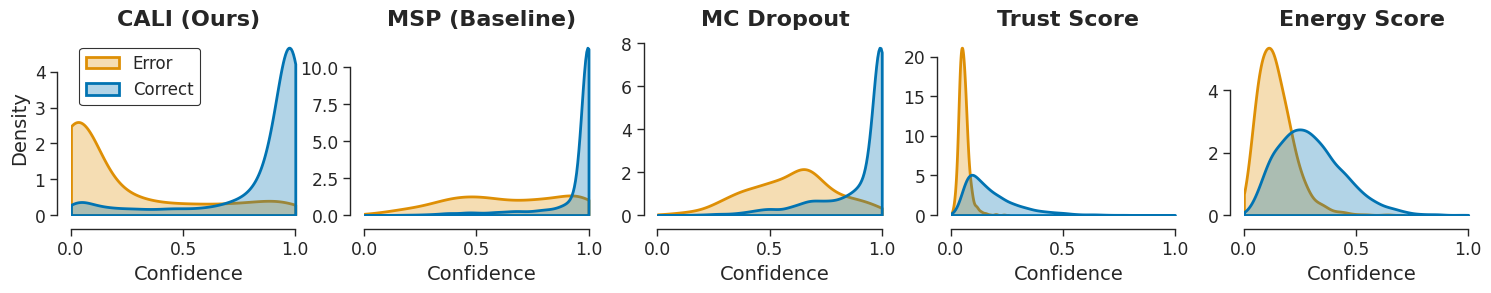

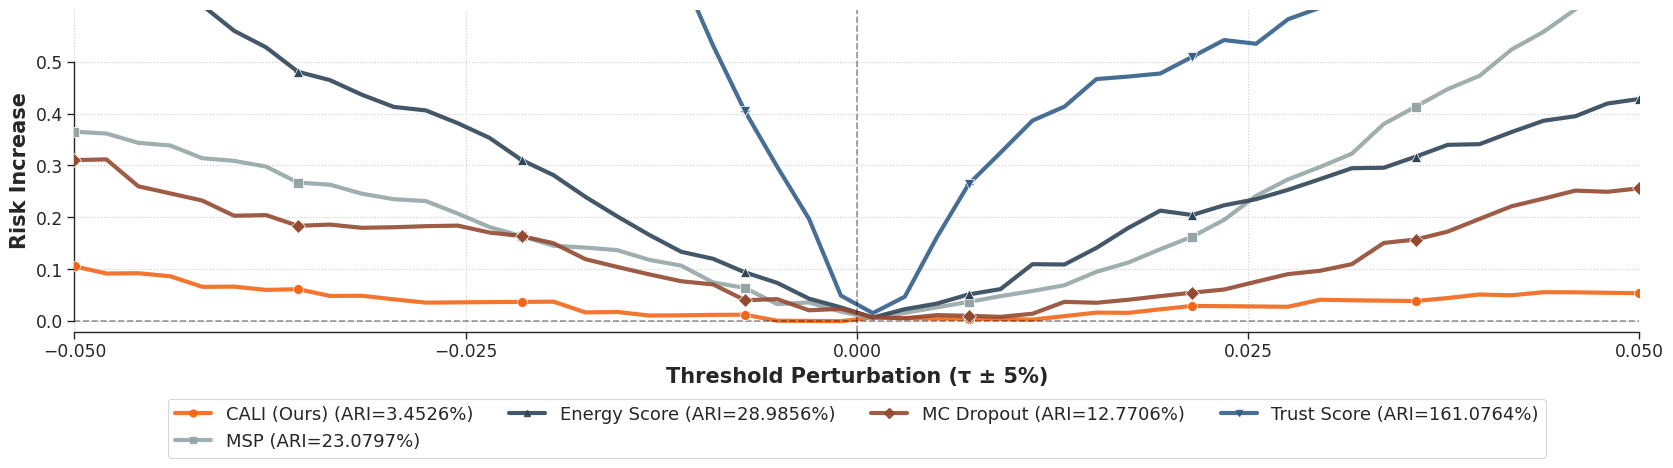

In [ ]:
from src.visualisations import plot_publication_separation, plot_operational_stability_failure

plot_publication_separation(detailed_results, methods_to_plot=['score_cali', 'score_softmax', 'score_mcdropout', 'score_trust', 'score_energy'])
plot_operational_stability_failure(seed=seed, delta=0.05)